In [1]:
%load_ext autoreload
%autoreload 2
# Always Restart Kernel after modifying backend file
from backend_aipw import *
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from sklearn.linear_model import Lasso, ElasticNet, LinearRegression, LogisticRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, GridSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from scipy.special import logit, expit
import matplotlib.pyplot as plt
#from celer import FusedLasso

In [2]:
def dgp1(rng, n):
    n_groups = 6       # e.g. (Low/Mid/High) × (Male/Female)
    # no sparsity

    X, _ = make_group_design(n, rng, n_groups)

    beta0 = rng.uniform(0.5, 1.5, size=n_groups)
    beta1 = beta0 + 1.0

    eps0 = rng.normal(0, 1, size=n)
    eps1 = rng.normal(0, 1, size=n)

    Y0 = X @ beta0 + eps0
    Y1 = X @ beta1 + eps1

    D = rng.binomial(1, 0.5, size=n)
    Y = D * Y1 + (1 - D) * Y0

    return X, D, Y, 1.0

In [3]:
def dgp2(rng, n):
    n_groups = int(0.1 * n)
    s_unique = 5       # strong group sparsity

    X, _ = make_group_design(n, rng, n_groups)

    beta0 = make_group_sparse_beta(n_groups, s_unique, rng)
    beta1 = beta0 + 1.0

    eps0 = rng.normal(0, 1, size=n)
    eps1 = rng.normal(0, 1, size=n)

    Y0 = X @ beta0 + eps0
    Y1 = X @ beta1 + eps1

    D = rng.binomial(1, 0.5, size=n)
    Y = D * Y1 + (1 - D) * Y0

    return X, D, Y, 1.0

In [4]:
def dgp3_anomaly(rng, n):
    n_groups = int(2.5 * n)
    s_unique = n_groups  # no sparsity at all

    X, _ = make_group_design(n, rng, n_groups)

    beta0 = rng.uniform(0.5, 1.5, size=n_groups)
    beta1 = beta0 + 1.0

    eps0 = rng.normal(0, 1, size=n)
    eps1 = rng.normal(0, 1, size=n)

    Y0 = X @ beta0 + eps0
    Y1 = X @ beta1 + eps1

    D = rng.binomial(1, 0.5, size=n)
    Y = D * Y1 + (1 - D) * Y0

    return X, D, Y, 1.0

In [5]:
def generate_dgp3_params(rng, n, dim_factor, spars_factor=None, fixed_s=None): # Takes as input the sample size, dimensionality factor, and sparsity factor
    # Hyperparameters controlling the strength of confounding and noise
    p_band = [0.2, 0.8]
    beta_strength = 2.5 # Before 3.0
    rho_strength = 0.8 # Before 1.2
    beta_noise = 0.5
    rho_noise = 0.3
    
    # Set Dimensionality
    n_groups = int(dim_factor * n)  # Dimensionality: grows with n
    
    # Set Sparsity
    if fixed_s is not None:
        nunique = fixed_s # Fixed Sparsity -> independent of n
    else:
        nunique = int(spars_factor * n_groups) # Relative Sparsity -> varies with n
    
    #s_unique = rng.normal(0, 1, nunique)
    #s = np.resize(s_unique, n_groups)
    s = np.zeros(n_groups)
    active_idx = rng.choice(n_groups, size=nunique, replace=False)
    s[active_idx] = rng.normal(0, 1, size=nunique)

    # Baseline outcomes (beta_g) are driven by latent 's'
    beta_g = beta_strength * s + beta_noise * rng.normal(0, 1, size=n_groups)
    # Propensity latent score (rho_latent) is ALSO driven by 's' -> Strong Confounding!
    rho_latent = rho_strength * s + rho_noise * rng.normal(0, 1, size=n_groups)

    # Bound Propensities cleanly strictly within p_band
    a = logit(p_band[0])
    b = logit(p_band[1])
    rho_g = np.clip(rho_latent, a, b)
    p_g = expit(rho_g) # convert back to probabilities

    return n_groups, beta_g, p_g

In [6]:
# --- New Supervisor-Inspired DGP 3 ---
def dgp3_supervisor(rng, n, n_groups, beta_g, p_g):
    """
    High-dimensional, strongly confounded DGP based on supervisor's R code.
    Breaks AIPW by combining sparsity with extreme correlation between 
    outcomes and propensity scores.
    """
    # Generate the Sample
    gid = rng.integers(0, n_groups, size=n)
    
    # One-hot encoding matrix
    X = np.zeros((n, n_groups))
    X[np.arange(n), gid] = 1.0

    # Map group parameters to individuals
    mu0 = beta_g[gid]
    mu1 = mu0 + 1.0  # Constant treatment effect tau = 1.0
    p = p_g[gid]

    # Assign treatment based on confounded propensity
    D = rng.binomial(1, p)

    # Generate Final Outcomes
    sigma_y = 1.0
    Y0 = mu0 + rng.normal(0, sigma_y, size=n)
    Y1 = mu1 + rng.normal(0, sigma_y, size=n)
    Y = D * Y1 + (1 - D) * Y0

    return X, D, Y, 1.0

In [7]:
"""
Plan - Used Machine Learners
1) OLS
1) Ridge
2) Lasso
3) Elastic Net
4) Random Forest
5) Gradient Boosting
6) CatBoost
7) Fused Lasso
8) XGBoost
9) Conditional Inference Forest
10) Logit Lasso
"""


learners_regime = {
    # Worst Estimator to Best Estimator
    "OLS": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),  # easy default, no tuning needed
    "Lasso": Lasso(max_iter=5000),
    "ElasticNet": ElasticNet(max_iter=5000),
    "RF": RandomForestRegressor(n_estimators=300, random_state=123, n_jobs=1),
    "GB": GradientBoostingRegressor(n_estimators=300, random_state=123),
    "CatBoost": CatBoostRegressor(verbose=0, random_state=123, iterations=300, thread_count=1),
    "XGBoost": XGBRegressor(n_estimators=300, random_state=123, n_jobs=1),
}

In [ ]:
## DGP 1
#print("DGP 1")
#tuned_learners_1 = tune_once(dgp1, learners_regime, n=100)
#print(monte_carlo(dgp1, tuned_learners_1, n=100, sims=100))
#
## DGP 2S
#print("DGP 2")
#tuned_learners_2 = tune_once(dgp2, learners_regime, n=100)
#print(monte_carlo(dgp2, tuned_learners_2, n=100, sims=100))

# DGP 3
# MC Parameters 
n = 100 # Sample size
dim_factor = 0.3 # Dimensionality factor: when dim_factor > 1.0 the number of groups exceeds the sample size, creating a high-dimensional setting 
spars_factor = 0.5 # Sparsity factor: when spars_factor = 1.0, there is no sparsity

print("DGP 3")
print("Sample Size", n)
print("Dimensionality", dim_factor)
print("Sparsity", spars_factor)
n_groups, beta_g, p_g = generate_dgp3_params(np.random.default_rng(0), n=n, dim_factor=dim_factor, spars_factor=spars_factor) # Generate parameters once for consistency across Monte Carlo
tuned_learners_3 = tune_once_parallel(dgp3_supervisor, learners_regime, n=n, n_groups=n_groups, beta_g=beta_g, p_g=p_g) # Tune parameters once 
print(monte_carlo_parallel(dgp3_supervisor, tuned_learners_3, n=n, sims=100, n_groups=n_groups, beta_g=beta_g, p_g=p_g))

Running simulation for group_size=10...
Running simulation for group_size=20...
Running simulation for group_size=30...
Running simulation for group_size=40...
Running simulation for group_size=50...
Running simulation for group_size=60...
Running simulation for group_size=70...
Running simulation for group_size=80...
Running simulation for group_size=90...
Running simulation for group_size=100...


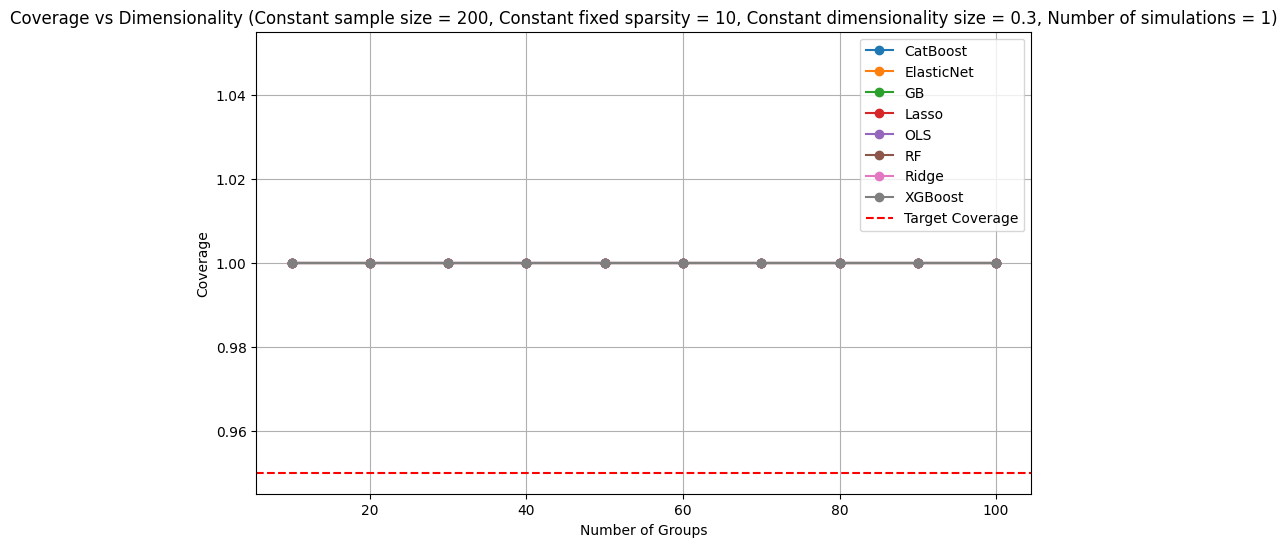

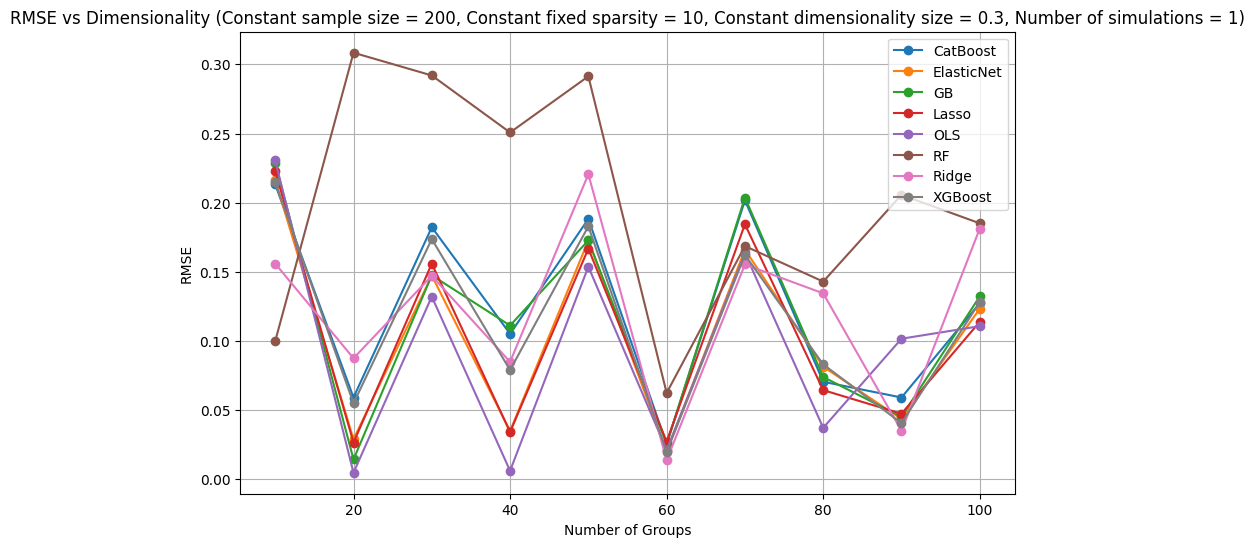

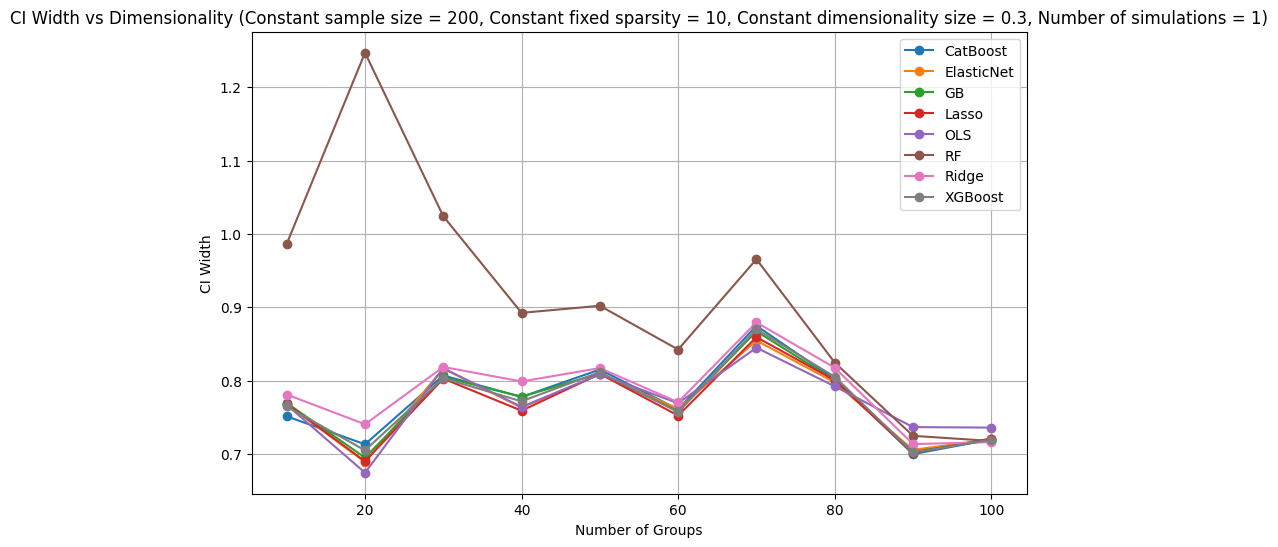

In [ ]:
# ANALYSIS - TOTAL GROUPS [Constand dimensionality size, Constant sample size, Constant fixed sparsity]
total_group_sizes = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]  # Factors of n to determine number of groups
fixed_dimensionality_size = 0.3 # 0.8 was too high
fixed_sample_size = 200
constant_fixed_sparsity = 10 # unique groups
simulations = 300
results_n = []

for tot in total_group_sizes:
    print(f"Running simulation for group_size={tot}...")
    # Define learner regime (Tuned or using robust defaults)
    n_groups = tot
    _, beta_g, p_g = generate_dgp3_params(
        np.random.default_rng(0),
        n=fixed_sample_size,
        dim_factor=n_groups / fixed_sample_size,  # <-- KEY FIX
        spars_factor=None,
        fixed_s=constant_fixed_sparsity
    )
    tuned_learners = tune_once_parallel(dgp3_supervisor, learners_regime, n=fixed_sample_size, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
    batch_results = monte_carlo_parallel(dgp3_supervisor, tuned_learners, n=fixed_sample_size, sims=simulations, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
    batch_results['group_size'] = tot
    results_n.append(batch_results.reset_index())

df_n = pd.concat(results_n)
# Create figures 
fig_cov, ax_cov = plt.subplots(figsize=(10,6))
fig_rmse, ax_rmse = plt.subplots(figsize=(10,6))
fig_ci, ax_ci = plt.subplots(figsize=(10,6))

for learner in df_n['Learner'].unique():
    subset = df_n[df_n['Learner'] == learner].sort_values("group_size")
    x = subset['group_size']
    ax_cov.plot(x, subset['Coverage'], marker='o', label=learner)
    ax_rmse.plot(x, subset['RMSE'], marker='o', label=learner)
    ax_ci.plot(x, subset['CI_Width'], marker='o', label=learner)

# Coverage formatting
ax_cov.axhline(y=0.95, color='r', linestyle='--', label='Target Coverage')
ax_cov.set_title(f"Coverage vs Number of Groups (Constant sample size = {fixed_sample_size}, Constant fixed sparsity = {constant_fixed_sparsity}, Constant dimensionality size = {fixed_dimensionality_size}, Number of simulations = {simulations})")
ax_cov.set_xlabel("Number of Groups")
ax_cov.set_ylabel("Coverage")
ax_cov.grid(True)
ax_cov.legend()

# RMSE formatting
ax_rmse.set_title(f"RMSE vs Number of Groups (Constant sample size = {fixed_sample_size}, Constant fixed sparsity = {constant_fixed_sparsity}, Constant dimensionality size = {fixed_dimensionality_size}, Number of simulations = {simulations})")
ax_rmse.set_xlabel("Number of Groups")
ax_rmse.set_ylabel("RMSE")
ax_rmse.grid(True)
ax_rmse.legend()

# CI_Width formatting
ax_ci.set_title(f"CI Width vs Number of Groups (Constant sample size = {fixed_sample_size}, Constant fixed sparsity = {constant_fixed_sparsity}, Constant dimensionality size = {fixed_dimensionality_size}, Number of simulations = {simulations})")
ax_ci.set_xlabel("Number of Groups")
ax_ci.set_ylabel("CI Width")
ax_ci.grid(True)
ax_ci.legend()

plt.show()

Running simulation for dim_factor=0.1...


Running simulation for dim_factor=0.2...
Running simulation for dim_factor=0.4...
Running simulation for dim_factor=0.6...
Running simulation for dim_factor=0.8...
Running simulation for dim_factor=1.0...
Running simulation for dim_factor=1.2...
Running simulation for dim_factor=1.4...
Running simulation for dim_factor=1.6...
Running simulation for dim_factor=1.8...
Running simulation for dim_factor=2.0...


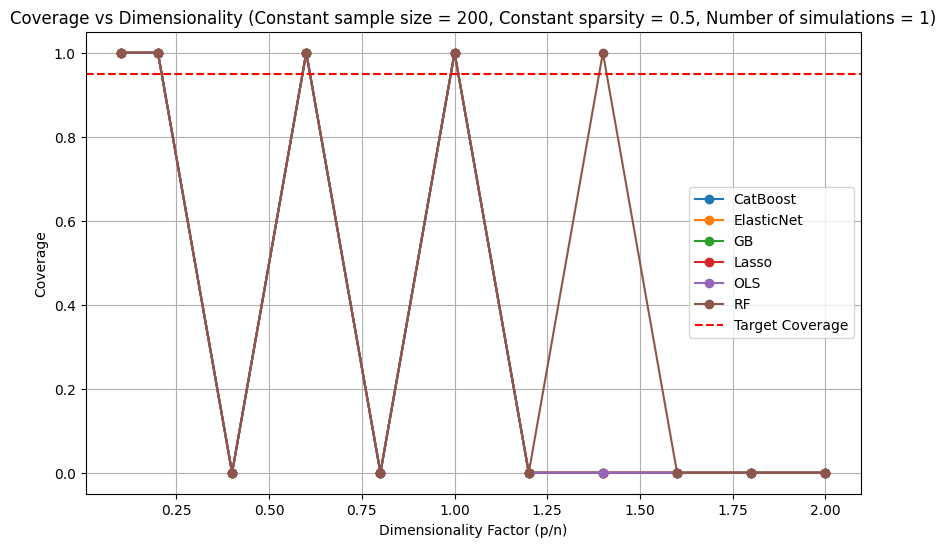

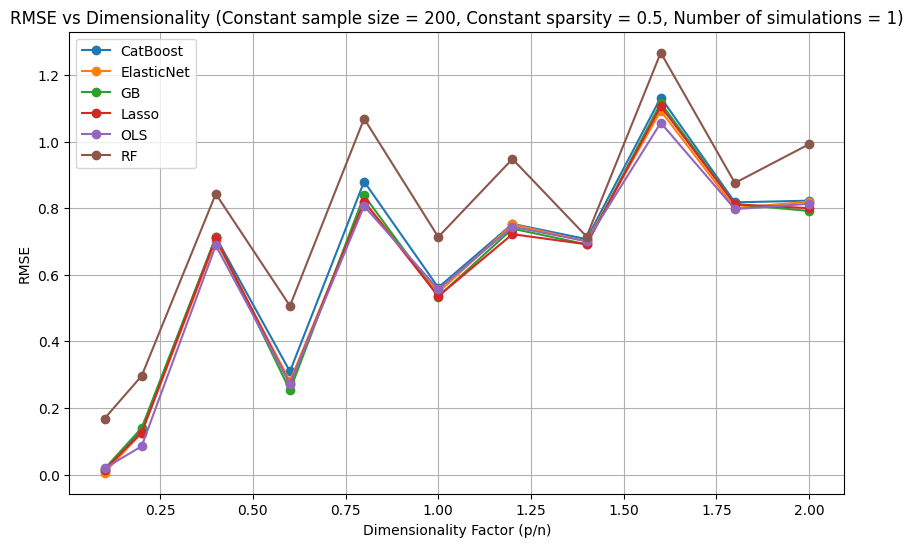

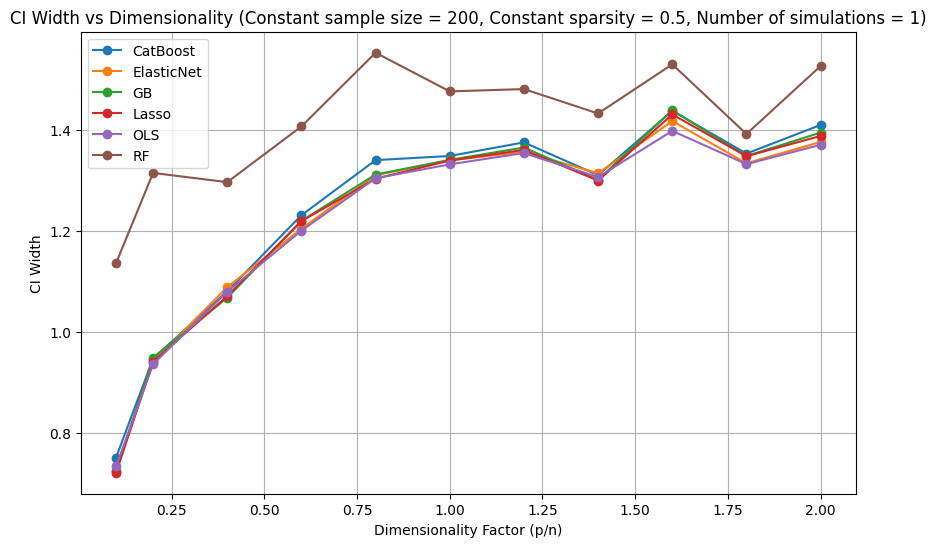

In [ ]:
# ANALYSIS - Dimensionality [Constant sample size, Constant relative sparsity]
dimensionality_sizes = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]  # Factors of n to determine number of groups
fixed_sample_size = 200
constant_relative_sparsity = 0.5
simulations = 300
results_n = []

for dim in dimensionality_sizes:
    print(f"Running simulation for dim_factor={dim}...")
    # Define learner regime (Tuned or using robust defaults)
    n_groups, beta_g, p_g = generate_dgp3_params(np.random.default_rng(0), n=fixed_sample_size, dim_factor=dim, spars_factor=constant_relative_sparsity)
    tuned_learners = tune_once_parallel(dgp3_supervisor, learners_regime, n=fixed_sample_size, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
    batch_results = monte_carlo_parallel(dgp3_supervisor, tuned_learners, n=fixed_sample_size, sims=simulations, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
    batch_results['dim_factor'] = dim
    results_n.append(batch_results.reset_index())

df_n = pd.concat(results_n)
# Create figures 
fig_cov, ax_cov = plt.subplots(figsize=(10,6))
fig_rmse, ax_rmse = plt.subplots(figsize=(10,6))
fig_ci, ax_ci = plt.subplots(figsize=(10,6))

for learner in df_n['Learner'].unique():
    subset = df_n[df_n['Learner'] == learner].sort_values("dim_factor")
    x = subset['dim_factor']
    ax_cov.plot(x, subset['Coverage'], marker='o', label=learner)
    ax_rmse.plot(x, subset['RMSE'], marker='o', label=learner)
    ax_ci.plot(x, subset['CI_Width'], marker='o', label=learner)

# Coverage formatting
ax_cov.axhline(y=0.95, color='r', linestyle='--', label='Target Coverage')
ax_cov.set_title(f"Coverage vs Dimensionality (Constant sample size = {fixed_sample_size}, Constant relative sparsity = {constant_relative_sparsity}, Number of simulations = {simulations})")
ax_cov.set_xlabel("Dimensionality Factor (p/n)")
ax_cov.set_ylabel("Coverage")
ax_cov.grid(True)
ax_cov.legend()

# RMSE formatting
ax_rmse.set_title(f"RMSE vs Dimensionality (Constant sample size = {fixed_sample_size}, Constant relative sparsity = {constant_relative_sparsity}, Number of simulations = {simulations})")
ax_rmse.set_xlabel("Dimensionality Factor (p/n)")
ax_rmse.set_ylabel("RMSE")
ax_rmse.grid(True)
ax_rmse.legend()

# CI_Width formatting
ax_ci.set_title(f"CI Width vs Dimensionality (Constant sample size = {fixed_sample_size}, Constant relative sparsity = {constant_relative_sparsity}, Number of simulations = {simulations})")
ax_ci.set_xlabel("Dimensionality Factor (p/n)")
ax_ci.set_ylabel("CI Width")
ax_ci.grid(True)
ax_ci.legend()

plt.show()

In [ ]:
# ANALYSIS - Dimensionality [Constant sample size, Constant fixed sparsity]
dimensionality_sizes = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]  # Factors of n to determine number of groups
fixed_sample_size = 200
constant_fixed_sparsity = 10 # unique groups
simulations = 300
results_n = []

for dim in dimensionality_sizes:
    print(f"Running simulation for dim_factor={dim}...")
    # Define learner regime (Tuned or using robust defaults)
    n_groups, beta_g, p_g = generate_dgp3_params(np.random.default_rng(0), n=fixed_sample_size, dim_factor=dim, spars_factor=None, fixed_s=constant_fixed_sparsity)
    tuned_learners = tune_once_parallel(dgp3_supervisor, learners_regime, n=fixed_sample_size, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
    batch_results = monte_carlo_parallel(dgp3_supervisor, tuned_learners, n=fixed_sample_size, sims=simulations, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
    batch_results['dim_factor'] = dim
    results_n.append(batch_results.reset_index())

df_n = pd.concat(results_n)
# Create figures 
fig_cov, ax_cov = plt.subplots(figsize=(10,6))
fig_rmse, ax_rmse = plt.subplots(figsize=(10,6))
fig_ci, ax_ci = plt.subplots(figsize=(10,6))

for learner in df_n['Learner'].unique():
    subset = df_n[df_n['Learner'] == learner].sort_values("dim_factor")
    x = subset['dim_factor']
    ax_cov.plot(x, subset['Coverage'], marker='o', label=learner)
    ax_rmse.plot(x, subset['RMSE'], marker='o', label=learner)
    ax_ci.plot(x, subset['CI_Width'], marker='o', label=learner)

# Coverage formatting
ax_cov.axhline(y=0.95, color='r', linestyle='--', label='Target Coverage')
ax_cov.set_title(f"Coverage vs Dimensionality (Constant sample size = {fixed_sample_size}, Constant relative sparsity = {constant_fixed_sparsity}, Number of simulations = {simulations})")
ax_cov.set_xlabel("Dimensionality Factor (p/n)")
ax_cov.set_ylabel("Coverage")
ax_cov.grid(True)
ax_cov.legend()

# RMSE formatting
ax_rmse.set_title(f"RMSE vs Dimensionality (Constant sample size = {fixed_sample_size}, Constant relative sparsity = {constant_fixed_sparsity}, Number of simulations = {simulations})")
ax_rmse.set_xlabel("Dimensionality Factor (p/n)")
ax_rmse.set_ylabel("RMSE")
ax_rmse.grid(True)
ax_rmse.legend()

# CI_Width formatting
ax_ci.set_title(f"CI Width vs Dimensionality (Constant sample size = {fixed_sample_size}, Constant relative sparsity = {constant_fixed_sparsity}, Number of simulations = {simulations})")
ax_ci.set_xlabel("Dimensionality Factor (p/n)")
ax_ci.set_ylabel("CI Width")
ax_ci.grid(True)
ax_ci.legend()

plt.show()

Running simulation for spars_factor=0.2...
Running simulation for spars_factor=0.4...
Running simulation for spars_factor=0.6...
Running simulation for spars_factor=0.8...
Running simulation for spars_factor=1.0...


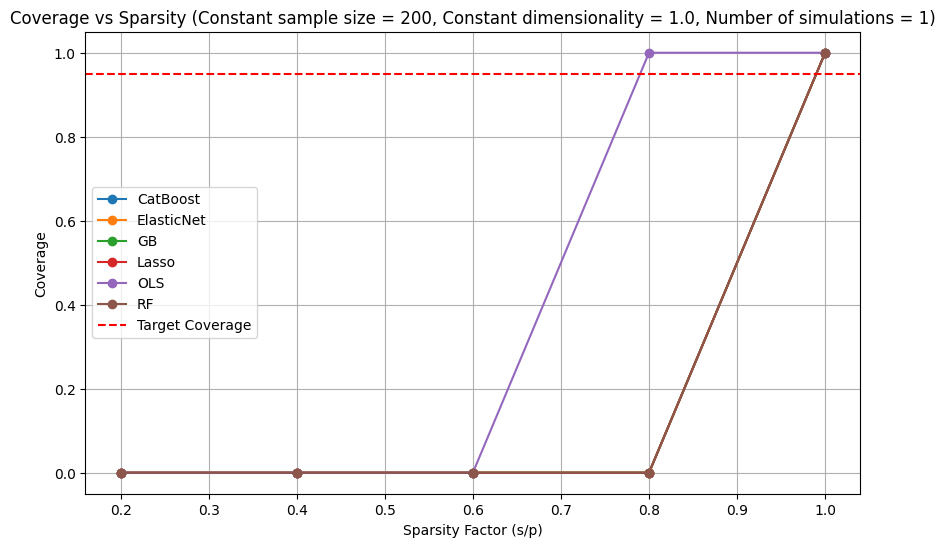

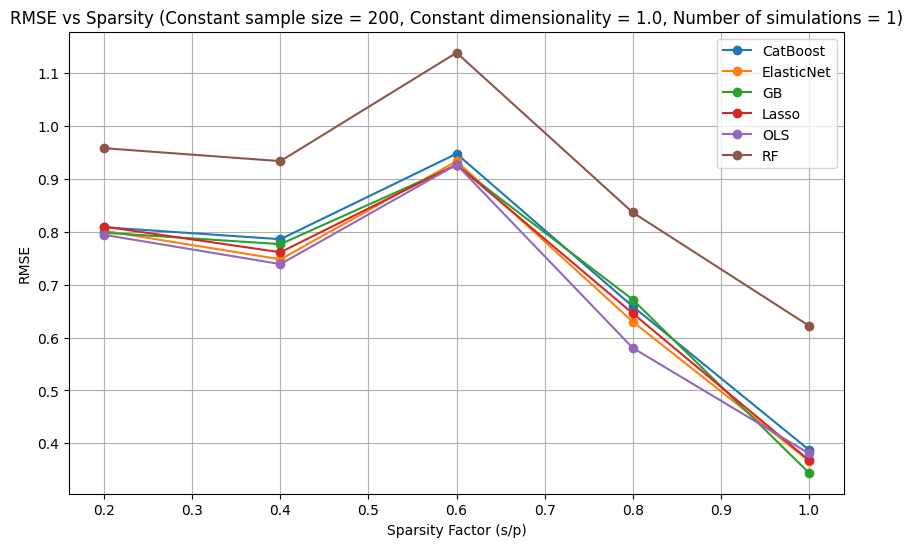

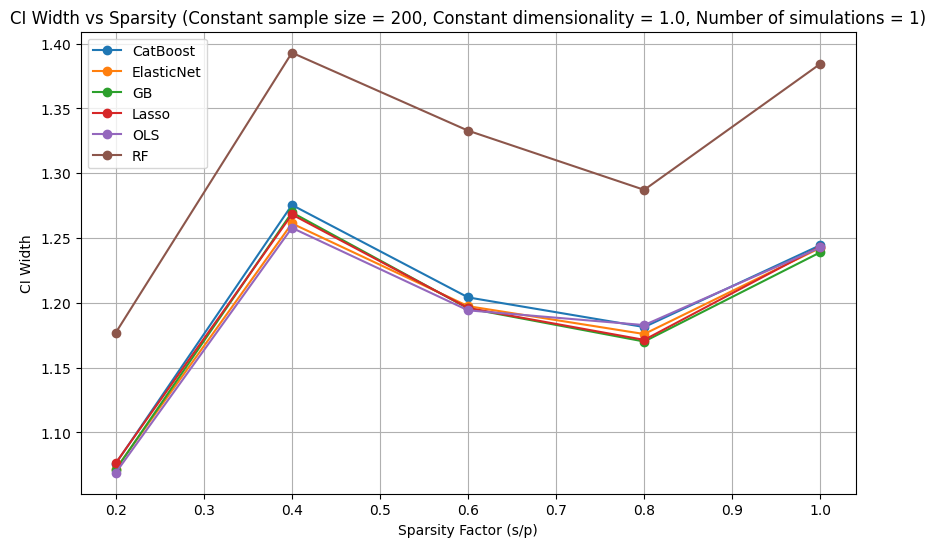

In [ ]:
# ANALYSIS - Sparsity
sparsity_sizes = [0.2, 0.4, 0.6, 0.8, 1.0] # Sparsity factors to determine number of unique signals
fixed_sample_size = 200
fixed_dimensionality_size = 1.0 # 0.8 was too high
simulations = 300
results_n = []

for spars in sparsity_sizes:
    print(f"Running simulation for spars_factor={spars}...")
    # Define learner regime (Tuned or using robust defaults)
    n_groups, beta_g, p_g = generate_dgp3_params(np.random.default_rng(0), n=fixed_sample_size, dim_factor=fixed_dimensionality_size, spars_factor=spars) 
    tuned_learners = tune_once_parallel(dgp3_supervisor, learners_regime, n=fixed_sample_size, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
    batch_results = monte_carlo_parallel(dgp3_supervisor, tuned_learners, n=fixed_sample_size, sims=simulations, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
    batch_results['spars_factor'] = spars
    results_n.append(batch_results.reset_index())

df_n = pd.concat(results_n)
# Create figures
fig_cov, ax_cov = plt.subplots(figsize=(10,6))
fig_rmse, ax_rmse = plt.subplots(figsize=(10,6))
fig_ci, ax_ci = plt.subplots(figsize=(10,6))

for learner in df_n['Learner'].unique():
    subset = df_n[df_n['Learner'] == learner].sort_values("spars_factor")
    x = subset['spars_factor']
    ax_cov.plot(x, subset['Coverage'], marker='o', label=learner)
    ax_rmse.plot(x, subset['RMSE'], marker='o', label=learner)
    ax_ci.plot(x, subset['CI_Width'], marker='o', label=learner)

# Coverage formatting
ax_cov.axhline(y=0.95, color='r', linestyle='--', label='Target Coverage')
ax_cov.set_title(f"Coverage vs Sparsity (Constant sample size = {fixed_sample_size}, Constant dimensionality = {fixed_dimensionality_size}, Number of simulations = {simulations})")
ax_cov.set_xlabel("Sparsity Factor (s/p)")
ax_cov.set_ylabel("Coverage")
ax_cov.grid(True)
ax_cov.legend()

# RMSE formatting
ax_rmse.set_title(f"RMSE vs Sparsity (Constant sample size = {fixed_sample_size}, Constant dimensionality = {fixed_dimensionality_size}, Number of simulations = {simulations})")
ax_rmse.set_xlabel("Sparsity Factor (s/p)")
ax_rmse.set_ylabel("RMSE")
ax_rmse.grid(True)
ax_rmse.legend()

# CI_Width formatting
ax_ci.set_title(f"CI Width vs Sparsity (Constant sample size = {fixed_sample_size}, Constant dimensionality = {fixed_dimensionality_size}, Number of simulations = {simulations})")
ax_ci.set_xlabel("Sparsity Factor (s/p)")
ax_ci.set_ylabel("CI Width")
ax_ci.grid(True)
ax_ci.legend()

plt.show()

Running simulation for sample_size=50...
Running simulation for sample_size=100...
Running simulation for sample_size=200...
Running simulation for sample_size=400...
Running simulation for sample_size=800...


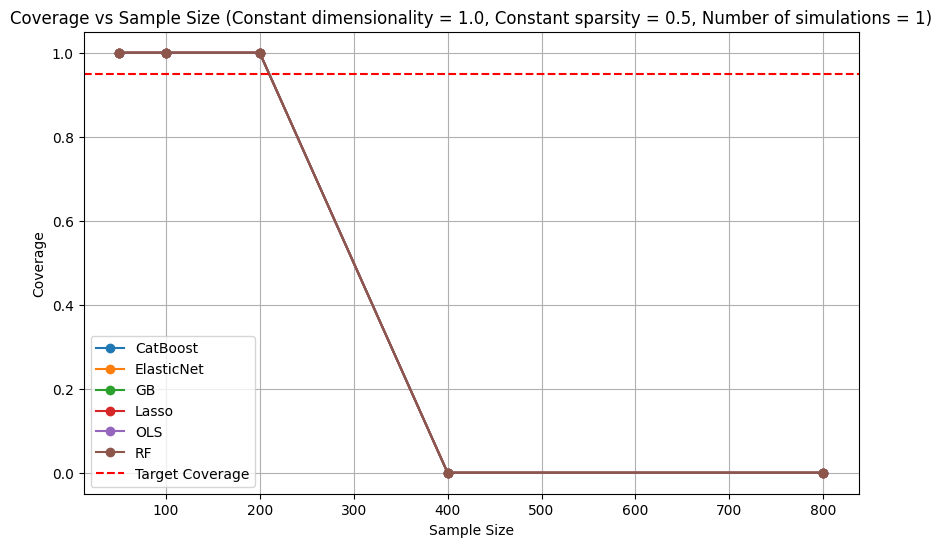

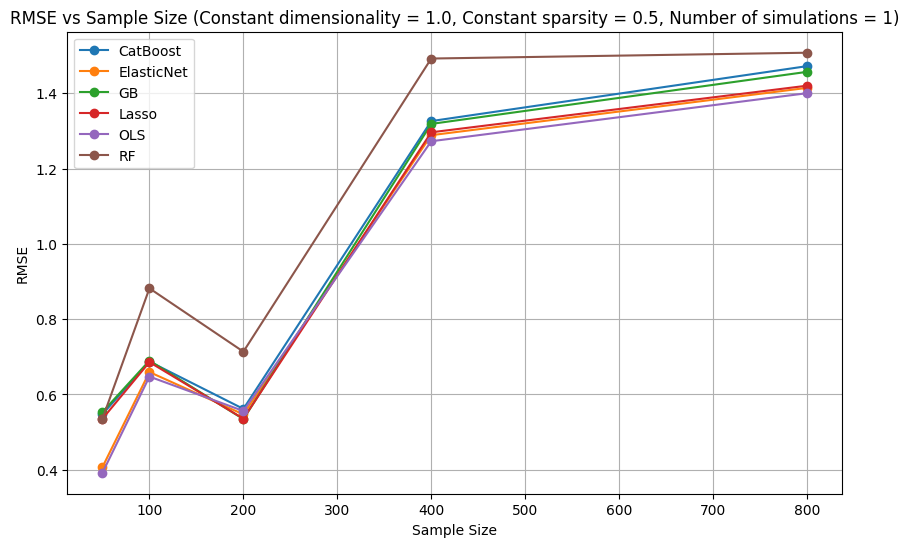

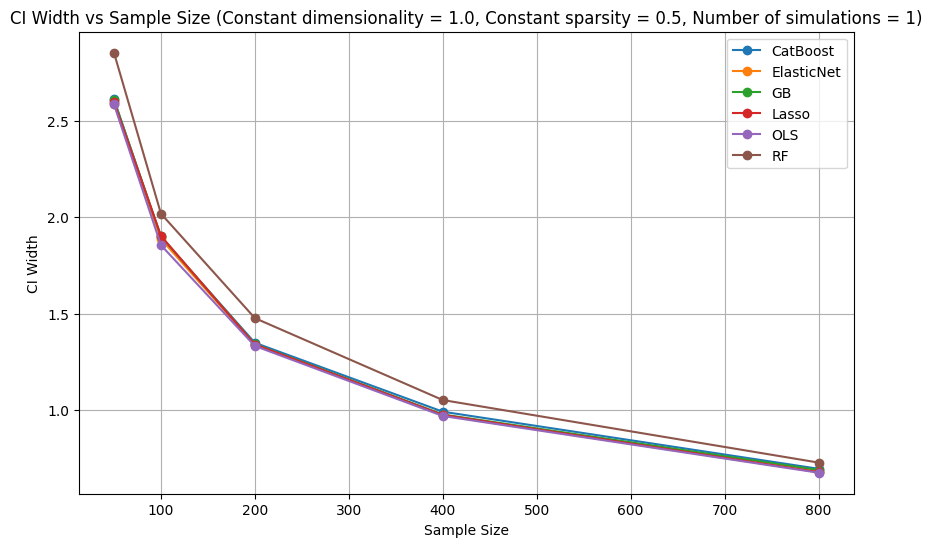

In [ ]:
# ANALYSIS - Sample Size
sample_sizes = [50, 100, 200, 400, 800] # Sample sizes to test
fixed_dimensionality_size = 1.0 # 0.8 was too high
fixed_sparsity_size = 0.5
simulations = 300
results_n = []

for n in sample_sizes:
    print(f"Running simulation for sample_size={n}...")
    # Define learner regime (Tuned or using robust defaults)
    n_groups, beta_g, p_g = generate_dgp3_params(np.random.default_rng(0), n=n, dim_factor=fixed_dimensionality_size, spars_factor=fixed_sparsity_size) 
    tuned_learners = tune_once_parallel(dgp3_supervisor, learners_regime, n=n, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
    batch_results = monte_carlo_parallel(dgp3_supervisor, tuned_learners, n=n, sims=simulations, n_groups=n_groups, beta_g=beta_g, p_g=p_g)
    batch_results['sample_size'] = n
    results_n.append(batch_results.reset_index())

df_n = pd.concat(results_n)
# Create figures
fig_cov, ax_cov = plt.subplots(figsize=(10,6))
fig_rmse, ax_rmse = plt.subplots(figsize=(10,6))
fig_ci, ax_ci = plt.subplots(figsize=(10,6))

for learner in df_n['Learner'].unique():
    subset = df_n[df_n['Learner'] == learner].sort_values("sample_size")
    x = subset['sample_size']
    ax_cov.plot(x, subset['Coverage'], marker='o', label=learner)
    ax_rmse.plot(x, subset['RMSE'], marker='o', label=learner)
    ax_ci.plot(x, subset['CI_Width'], marker='o', label=learner)

# Coverage formatting
ax_cov.axhline(y=0.95, color='r', linestyle='--', label='Target Coverage')
ax_cov.set_title(f"Coverage vs Sample Size (Constant dimensionality = {fixed_dimensionality_size}, Constant sparsity = {fixed_sparsity_size}, Number of simulations = {simulations})")
ax_cov.set_xlabel("Sample Size")
ax_cov.set_ylabel("Coverage")
ax_cov.grid(True)
ax_cov.legend()

# RMSE formatting
ax_rmse.set_title(f"RMSE vs Sample Size (Constant dimensionality = {fixed_dimensionality_size}, Constant sparsity = {fixed_sparsity_size}, Number of simulations = {simulations})")
ax_rmse.set_xlabel("Sample Size")
ax_rmse.set_ylabel("RMSE")
ax_rmse.grid(True)
ax_rmse.legend()

# CI_Width formatting
ax_ci.set_title(f"CI Width vs Sample Size (Constant dimensionality = {fixed_dimensionality_size}, Constant sparsity = {fixed_sparsity_size}, Number of simulations = {simulations})")
ax_ci.set_xlabel("Sample Size")
ax_ci.set_ylabel("CI Width")
ax_ci.grid(True)
ax_ci.legend()

plt.show()

